# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Tangaran, Grisby Paul James L. Tangaran
- _Student No._: 2024-02777
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Problem 1: Hamiltonian Matrix and its Eigs
![First 5 Eigenstates of the Quantum Harmonic Oscillator](6-problem-1.png)

Figure 1. First 5 Eigenstates of the Quantum Harmonic Oscillator

The Hamiltonian matrix was constructed by discretizing the kinetic energy operator via the central finite-difference method and expressing the harmonic potential $V(x)$ as a square diagonal matrix. The resulting matrix eigenvalue problem, $H\psi = E\psi$, was solved using np.linalg.eigh across a spatial grid of $N = 100$ points. The calculated energy eigenvalues are discrete and uniformly spaced by $\Delta E \approx \hbar\omega = 0.8$, as given in the problem. The ground state yields a zero-point energy of $E_0 = 0.40$, rising sequentially to $E_4 = 3.59$ for the fifth eigenstate. Plotted as vertical offsets $f_n = \psi_n + E_n$, each $n$-th eigenfunction displays exactly $n$ spatial nodes. Furthermore, the wavefunctions visibly extend beyond the classical turning points set by $V(x) = \frac{1}{2}m\omega^2x^2$ before exponentially decaying, successfully capturing the phenomenon of quantum tunneling in classically forbidden regions.  


### Problem 2: Harmonic Oscillator in an Electric Field
![Numerical vs Theoretical Eigenenergies (100 States)](6-problem-2_1.png)

Figure 1. Numerical vs Theoretical Eigenenergies (50 States)

![Potential and Ground State Probability of the Ground State](6-problem-2_2.png)

Figure 3. Potential and Ground State Probability of the Ground State

As shown in Figure 2, the numerical eigenenergies calculated via the matrix method closely match the theoretical values for lower energy states, up to approximately $n = 30$. At higher energy states, the numerical results diverge positively from the theoretical predictions. This occurs because higher-energy wavefunctions spread wider and oscillate more rapidly. The finite spatial grid ($x \in [-10, 10]$) acts like a rigid box, artificially compressing these broader wavefunctions and overestimating their energy eigenvalues. 

Furthermore, Figure 3 demonstrates that the ground-state behavior makes physical sense. The addition of the uniform electric field introduces a linear term $qEx$, which shifts the minimum of the harmonic potential to the left and lowers its minimum energy. The ground-state probability density, $\vert{}\psi_0(x)\vert{}^2$, retains its standard Gaussian shape and is properly centered exactly over the newly displaced minimum of the effective potential $V(x)$.

### Other comments
- None


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [1]:
# code here
import numpy as np
import matplotlib.pyplot as plt

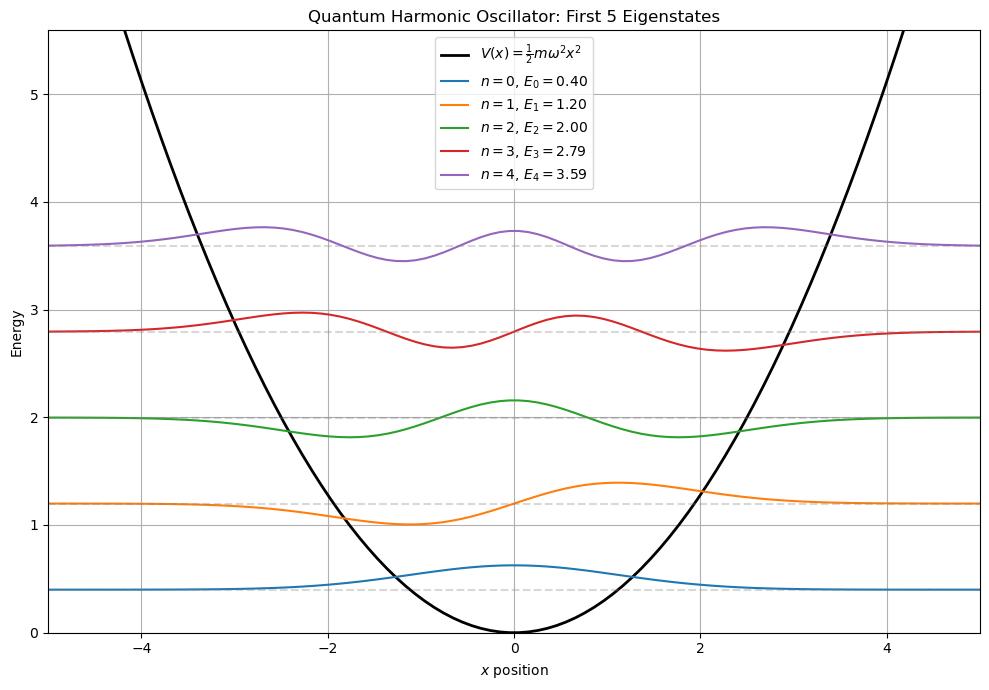

In [2]:
def hamiltonian(x_pos, potential_array, mass, hbar):
    """Constructs the discrete Hamiltonian matrix H = T + V for a 1D system using finite differences."""
    N = len(x_pos) #
    dx = np.abs(x_pos[1]-x_pos[0]) #
    # Construct second derivative matrix
    diag = -2 * np.eye(N) #-2 in the main diagonal
    off_diag = np.eye(N, k=-1) + np.eye(N, k=1) # Off-diagonals (+1 above and below)
    D2 = (diag + off_diag)/(dx**2) 
    
    T = - ( (hbar**2) / ( 2*m) )* D2 #Kinetic Energy
    V = np.diag(potential_array) #Potential Energy array
    
    return T + V 
    
#Parameters
m = 1
hbar = 1
w = 0.8
N_points = 100
x =  np.linspace(-5, 5, N_points)
dx = x[1] - x[0]

# Define harmonic oscillator potential:
V_x = 0.5*m*(w**2)*(x**2)

H = hamiltonian(x, V_x, m, hbar)

# Solve the time-independent Schrödinger equation
eigenvalues, eigenvectors = np.linalg.eigh(H)


plt.figure(figsize=(10, 7))
plt.plot(x, V_x, color='black', linewidth=2, label=r'$V(x) = \frac{1}{2}m\omega^2 x^2$')

# Plot the first 5 energy eigenstates
for n in range(5):
    E_n = eigenvalues[n]
    psi_n = eigenvectors[:, n]

    f_n = psi_n + E_n

    plt.plot(x, f_n, label=f'$n={n}$, $E_{n}={E_n:.2f}$')
    plt.axhline(E_n, color='gray', linestyle='--', alpha=0.3)

plt.ylim(0, eigenvalues[4] + 2)
plt.xlim(-5, 5)
plt.xlabel('$x$ position')
plt.ylabel('Energy')
plt.title('Quantum Harmonic Oscillator: First 5 Eigenstates')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('6-problem-1.png')
plt.show()
    

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
*   This code solves the time-independent Schrödinger equation for a quantum harmonic oscillator by discretizing space across an $N=100$ grid. The kinetic energy operator was built using a finite-difference matrix and combined with a diagonal potential matrix $V(x)$, allowing np.linalg.eigh() to solve the matrix eigenvalue problem $H\psi = E\psi$. Finally, each eigenfunction is plotted vertically offset by its energy eigenvalue ($f_n = \psi_n + E_n$) alongside $V(x)$ to clearly illustrate node counts and quantum tunneling at each state.

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

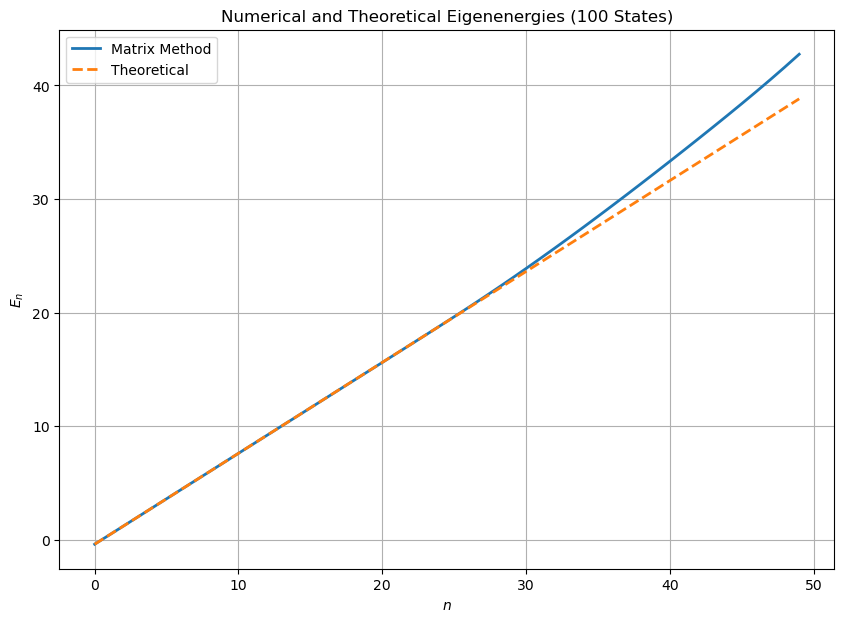

In [3]:
qE = 1  # Since E = q^-1, q*E = +1
N_points = 1001
x = np.linspace(-10, 10, N_points)
dx = x[1]-x[0]

# Potential energy function V(x)
potential = 0.5 * m * (w**2) * (x**2) + qE * x
H = hamiltonian(x, potential, m, hbar)

# Solve matrix eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eigh(H)

# Array of the first 50 numerically calculated eigenvalues
E_hundred = eigenvalues[:50]
n_hundred = np.arange(50)

# Analytical energy eigenvalues
E_n = hbar * w * (n_hundred + 0.5) - ((qE**2) / (2 * m * (w**2)))

plt.figure(figsize=(10, 7))
plt.plot(n_hundred, E_hundred, label="Matrix Method", linewidth=2)
plt.plot(n_hundred, E_n, label="Theoretical", linestyle="--", linewidth=2)

plt.xlabel("$n$")
plt.ylabel("$E_n$")
plt.title("Numerical and Theoretical Eigenenergies (100 States)")
plt.legend()
plt.grid()  
plt.savefig('6-problem-2_1.png')
plt.show()

Total Integrated Probability: 1.000000


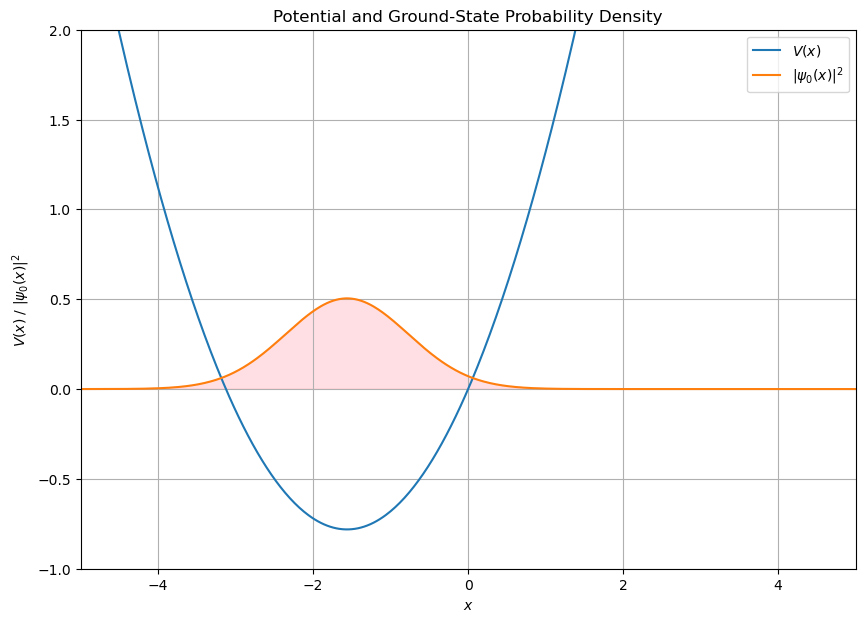

In [4]:
# 1. Extract raw unnormalized eigenvector from matrix solution
psi_raw = eigenvectors[:, 0]

norm_sq = np.trapz(np.abs(psi_raw)**2, x)

psi_0 = psi_raw / np.sqrt(norm_sq)

# 4. Compute probability density
prob_density = np.abs(psi_0)**2

# 5. Verify integral equals 1.0
total_prob = np.trapz(prob_density, x)
print(f"Total Integrated Probability: {total_prob:.6f}")

# Plotting
plt.figure(figsize=(10, 7))
plt.plot(x, potential, label="$V(x)$")
plt.plot(x, prob_density, label=r"$|\psi_0(x)|^2$")
plt.fill_between(x, prob_density, color="pink", alpha=0.5)

plt.ylim(-1, 2)
plt.xlim(-5, 5)

plt.xlabel("$x$")
plt.ylabel("$V(x)$ / $|\psi_0(x)|^2$")
plt.title("Potential and Ground-State Probability Density")
plt.legend()
plt.grid()
plt.savefig('6-problem-2_2.png')
plt.show()

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* This code evaluates the energy levels and ground-state wavefunction of a quantum harmonic oscillator in a uniform electric field across a spatial grid ($N=1001$). The matrix Hamiltonian is solved using np.linalg.eigh() to compare the numerical eigenenergies against theoretical values. Finally, the raw ground-state eigenvector is explicitly normalized via trapezoidal integration (np.trapz) to plot the probability density $\vert{}\psi_0(x)\vert{}^2$ centered over the displaced potential minimum.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)